<div style="font-family: 'Times New Roman', serif; text-align: center; padding: 20px 0;">

<hr style="border: none; border-top: 1px solid #444;">

<p style="font-size: 13px; letter-spacing: 3px; color: #666; margin: 15px 0 8px 0;">
PATCH COMPOSITION
</p>

<p style="font-size: 32px; font-weight: bold; margin: 0 0 15px 0;">
Patch - Solar Orbiter
</p>

<hr style="border: none; border-top: 1px solid #444; width: 80%;">

</div>

In [32]:
import numpy             as np
import pandas            as pd
import speasy            as spz
import matplotlib.pyplot as plt

from matplotlib        import rcParams
from scipy.interpolate import interp1d
from scipy             import interpolate, stats
from datetime          import datetime, timedelta

from src.f_patch import average, load_data_solo

In [33]:
""" Plot Config """
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 13
rcParams['axes.titlesize'] = 18
rcParams['axes.labelsize'] = 15
rcParams['xtick.labelsize'] = 13
rcParams['ytick.labelsize'] = 13
rcParams['legend.fontsize'] = 14
rcParams['figure.titlesize'] = 18

rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.25
rcParams['grid.linestyle'] = '--'
rcParams['grid.linewidth'] = 0.5

In [34]:
""" Time Config """
start_SOLO = datetime(2025, 3, 17) # Fast-wind SOOP
stop_SOLO  = datetime(2025, 4, 13)

In [39]:
""" Get Data """ 
data_solo = load_data_solo(start_SOLO, stop_SOLO)
data_solo

,car_lon,car_lat,r_sun,Np,Vp_r,Vp_t,Vp_n,Tp,Br,Bt,Bn
2025-03-17 00:00:00.177,176.418162,-15.283978,0.423160,3.643799,379.363373,94.679123,-41.890675,33.653782,-34.235580,15.949701,1.559939
2025-03-17 00:00:01.177,176.418041,-15.283984,0.423160,3.947945,376.990051,101.582245,-38.163555,32.619854,-33.965054,16.377220,1.759863
2025-03-17 00:00:02.177,176.417921,-15.283989,0.423160,3.706120,383.627808,101.958160,-43.232319,34.343788,-33.729202,16.882778,0.961502
2025-03-17 00:00:03.177,176.417800,-15.283994,0.423160,3.876642,375.535400,108.722351,-42.814110,36.546280,-33.706581,16.975887,1.033507
2025-03-17 00:00:04.177,176.417680,-15.284000,0.423160,4.515287,366.548828,106.747696,-52.864479,35.308254,-33.808865,16.623711,0.720834
...,...,...,...,...,...,...,...,...,...,...,...
2025-04-12 23:59:52.604,-46.248035,12.034859,0.395143,95.295967,433.878418,-16.478552,-0.780262,35.340309,-40.739613,21.427841,-0.186582
2025-04-12 23:59:53.604,-46.248150,12.034869,0.395143,95.227074,434.101776,-16.725679,-1.237523,36.176323,-41.478874,19.683432,-0.562432
2025-04-12 23:59:54.604,-46.248266,12.034879,0.395143,91.542542,430.164062,-21.756344,-4.196255,35.871956,-43.493576,16.097651,-0.652600
2025-04-12 23:59:55.604,-46.248381,12.034889,0.395143,93.915497,429.115967,-25.754433,-3.405156,35.617874,-42.903080,16.128126,-1.086294


In [42]:
""" Derived Parameters """
# alpha_abundance_solo = data_solo['Na'] / (data_solo['Na'] + data_solo['Np'])*100

' Derived Parameters '

Text(1.08, 0.5, '— $r$ $[AU]$')

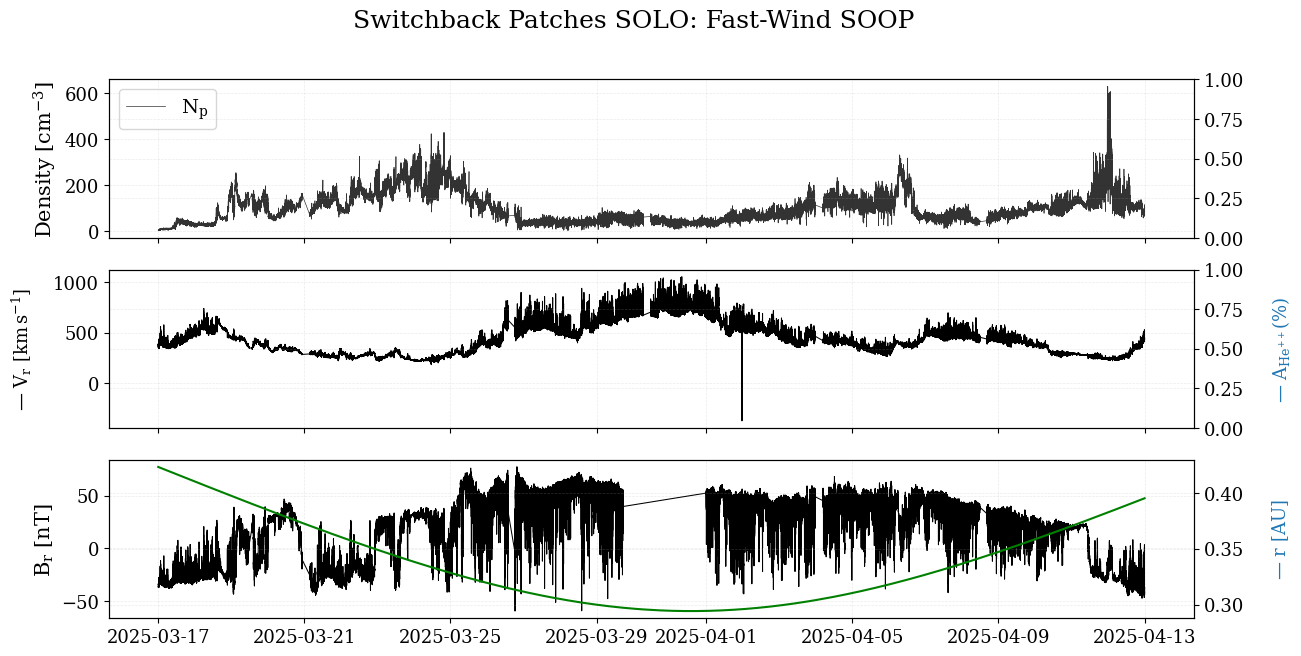

In [46]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(14,7))
fig.suptitle("Switchback Patches SOLO: Fast-Wind SOOP")

plt.rcParams["mathtext.default"] = "regular"

time_index = data_solo.index

ax1b = ax1.twinx()
ax1.plot(time_index, data_solo['Np'], label='$N_p$', color='black', linewidth='0.5', alpha=0.8)
# ax1b.plot(Na_PSP.index, Na_PSP.iloc[:,0], label='$N_a$', color='tab:red', linewidth='0.5', alpha=0.8)
ax1.legend(loc='upper left')
# ax1b.legend(loc='upper right')
ax1.set_ylabel('Density $[cm^{-3}]$')

ax2b = ax2.twinx()
ax2.plot(time_index, data_solo['Vp_r'], label='$V_p$', color='black', linewidth='0.75')
# ax2b.plot(time_index,alpha_abundance_PSP_average,label=r'$\alpha _{\%}$',color='tab:blue',linewidth=0.75,alpha=0.8)
# ax2b.set_yscale('log')
ax2.annotate(
    r'— $V_r$ $[km\,s^{-1}]$',
    xy=(-0.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='black')

ax2b.annotate(
    r'— $A_{He^{++}} (\%)$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')

ax3b = ax3.twinx()
ax3.plot(time_index, data_solo['Br'], color ='black', linewidth='0.75')
ax3b.plot(time_index, data_solo['r_sun'], color='green')
ax3.set_ylabel('$B_r$ $[nT]$')
ax3b.annotate(
    r'— $r$ $[AU]$',
    xy=(1.08, 0.5),
    xycoords='axes fraction',
    rotation=90,
    va='center',
    ha='center',
    color='tab:blue')
# ax3b.set_ylim(None,0.2)

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Angular Displacement
</p>

</div>

In [48]:
""" Ephemeris Data """
phi, theta, solo_r_sun = data_solo['car_lon'], data_solo['car_lat'], data_solo['r_sun']

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Fourier Analysis
</p>

</div>

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Velocity

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 0px solid #888;
">

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Alpha Abundance

<div style="
    font-family: 'Times New Roman', serif;
    margin: 35px 0 20px 0;
    padding-bottom: 8px;
    border-bottom: 1px solid #888;
">

<p style="
    font-size: 12px;
    letter-spacing: 2.5px;
    color: #666;
    margin: 0 0 5px 0;
    text-transform: uppercase;
">
PATCH COMPOSITION - SOLO
</p>

<p style="
    font-size: 24px;
    font-weight: bold;
    margin: 0;
">
Correlation
</p>

</div>